
# Clasificador PLS vs Lenguaje Técnico (v2, criterios avanzados)
Este notebook cumple con:
- **Varios clasificadores binarios** para identificar lenguaje sencillo (PLS).
- **Embeddings contextuales** (Transformers) y **embeddings dispersos** (TF–IDF).
- **Distintas cabezas de clasificación**: lineal, **MLP**, y **ensamble** (promedio ponderado).
- **Evaluación rigurosa**: métricas (Accuracy, Precision, Recall, F1 macro, ROC-AUC, PR-AUC), **split train/val/test** y **validación cruzada** para modelos scikit-learn.


In [1]:
!unzip bridging-the-gap-in-health-literacy-main.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/773-MT_MED_9011_page8.txt  
  inflating: __MACOSX/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/._773-MT_MED_9011_page8.txt  
  inflating: bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/3142-MT_MED_9011_page8.txt  
  inflating: __MACOSX/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/._3142-MT_MED_9011_page8.txt  
  inflating: bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Trial Summaries/not_taken_texts/med/10991-MT_MED_9011_page4.txt  
  inflating: __MACOSX/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sour

In [ ]:
!pip install -U scikit-learn pandas numpy matplotlib joblib transformers datasets evaluate torch sentence-transformers pypdf2

In [ ]:
# --- Núcleo científico alineado con Colab / RAPIDS ---
%pip install -q \
  numpy==2.0.2 \
  pandas==2.2.2 \
  pyarrow==19.0.0 \
  scikit-learn==1.6.1

# --- PyTorch CUDA 12.6 (coincide con torchvision 0.23.0 de Colab) ---
%pip install -q --extra-index-url https://download.pytorch.org/whl/cu126 \
  torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0

# --- Hugging Face + métricas (satisface torchtune, peft y sentence-transformers) ---
%pip install -q \
  transformers==4.44.2 \
  tokenizers==0.19.1 \
  datasets==2.20.0 \
  accelerate==0.33.0 \
  evaluate==0.4.2

# --- Librerías que te estaban faltando (quedaban “no instaladas”) ---
%pip install -q \
  peft==0.17.1 \
  sentence-transformers==5.1.1 \
  fastai==2.8.4 \
  torchtune==0.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:

# %pip install -U scikit-learn pandas numpy matplotlib joblib transformers datasets evaluate torch sentence-transformers pypdf2
import os, json, time, math, random, gc
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score,
                             average_precision_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils import shuffle
from joblib import dump

print("Imports OK")

Imports OK


In [2]:
# === CONFIG ===
BASE_DIR = Path('/content/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources')
OUTPUT_DIR = Path('./outputs_pls_classifier_v2'); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PARSE_PDFS = False
PDF_MIN_CHARS = 200

LABEL_BY_SOURCE_DEFAULT = {
    'Pfizer': 'pls',
    'Trial Summaries': 'pls',
    'ClinicalTrials.gov': 'non_pls'
}
LABEL_TO_INT = {'non_pls': 0, 'pls': 1}
INT_TO_LABEL = {0: 'non_pls', 1: 'pls'}

SOURCES = ['Cochrane','Pfizer','Trial Summaries','ClinicalTrials.gov']
RANDOM_STATE = 17
DEFAULT_TEST_SIZE = 0.2
VAL_SIZE = 0.15
DEDUPLICATE = True

print('BASE_DIR =', BASE_DIR.resolve())
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())

BASE_DIR = /content/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources
OUTPUT_DIR = /content/outputs_pls_classifier_v2


In [3]:

def read_txt_file(path: Path) -> Optional[str]:
    try:
        t = path.read_text(encoding='utf-8', errors='ignore').strip()
        return t if t else None
    except Exception:
        return None

def read_pdf_file(path: Path) -> Optional[str]:
    if not PARSE_PDFS:
        return None
    try:
        from PyPDF2 import PdfReader
    except Exception:
        return None
    try:
        reader = PdfReader(str(path))
        parts = []
        for page in reader.pages:
            txt = page.extract_text() or ''
            if txt and len(txt) >= PDF_MIN_CHARS:
                parts.append(txt)
        text = '\n'.join(parts).strip()
        return text if text else None
    except Exception:
        return None

def iter_texts_in_dir(root: Path, exts=('.txt',)) -> List[Path]:
    return [p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in exts]

def normalize_for_dedup(s: str) -> str:
    return ' '.join((s or '').lower().split())

def load_cochrane(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Cochrane'
    if not root.exists(): return out
    for subset in ['train','test']:
        for cls in ['pls','non_pls']:
            cdir = root / subset / cls
            if not cdir.exists(): continue
            for p in iter_texts_in_dir(cdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':cls,'source':'Cochrane','subset':subset,'path':str(p)})
    return out

def load_pfizer(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Pfizer'
    if not root.exists(): return out
    for subset in ['train','test']:
        sdir = root / subset
        if sdir.exists():
            for p in iter_texts_in_dir(sdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Pfizer','pls'),
                                'source':'Pfizer','subset':subset,'path':str(p)})
    for p in (root / 'original_pfizer_texts').rglob('*.pdf') if (root / 'original_pfizer_texts').exists() else []:
        t = read_pdf_file(p)
        if t:
            out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Pfizer','pls'),
                        'source':'Pfizer','subset':'unspecified','path':str(p)})
    return out

def load_trial_summaries(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Trial Summaries'
    if not root.exists(): return out
    for tf in ['med','alx']:
        tfdir = root / tf
        if tfdir.exists():
            for p in iter_texts_in_dir(tfdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Trial Summaries','pls'),
                                'source':'Trial Summaries','subset':'unspecified','path':str(p)})
    orig = root / 'original_texts'
    if orig.exists():
        for p in orig.rglob('*.pdf'):
            t = read_pdf_file(p)
            if t:
                out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Trial Summaries','pls'),
                            'source':'Trial Summaries','subset':'unspecified','path':str(p)})
    return out

def load_clinicaltrials_gov(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'ClinicalTrials.gov'
    if not root.exists(): return out
    for subset in ['train','test']:
        sdir = root / subset
        if sdir.exists():
            for p in iter_texts_in_dir(sdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('ClinicalTrials.gov','non_pls'),
                                'source':'ClinicalTrials.gov','subset':subset,'path':str(p)})
    return out

def load_all(base_dir: Path, sources: List[str]) -> pd.DataFrame:
    recs = []
    if 'Cochrane' in sources: recs += load_cochrane(base_dir)
    if 'Pfizer' in sources: recs += load_pfizer(base_dir)
    if 'Trial Summaries' in sources: recs += load_trial_summaries(base_dir)
    if 'ClinicalTrials.gov' in sources: recs += load_clinicaltrials_gov(base_dir)
    df = pd.DataFrame(recs)
    if df.empty:
        print('⚠️ No se encontraron textos. Revisa rutas.')
        return df
    df['label_int'] = df['label'].map({'non_pls':0,'pls':1})
    df['subset'] = df['subset'].fillna('unspecified')
    df['n_chars'] = df['text'].str.len()
    return df

df_raw = load_all(BASE_DIR, SOURCES)
print('Total textos:', len(df_raw))
df_raw.head(3)

Total textos: 61363


,text,label,source,subset,path,label_int,n_chars
0,Cannabis and cannabinoids for people with mult...,pls,Cochrane,train,/content/bridging-the-gap-in-health-literacy-m...,1,3696
1,The autogenic drainage breathing technique for...,pls,Cochrane,train,/content/bridging-the-gap-in-health-literacy-m...,1,2293
2,Medication as a treatment for long‐term medica...,pls,Cochrane,train,/content/bridging-the-gap-in-health-literacy-m...,1,4110


Deduplicación: 61363 -> 61325 (elim 38)

Etiquetas:
label
non_pls    39525
pls        21800
Name: count, dtype: int64

Fuentes:
source
Cochrane              58940
Trial Summaries        1034
ClinicalTrials.gov      751
Pfizer                  600
Name: count, dtype: int64


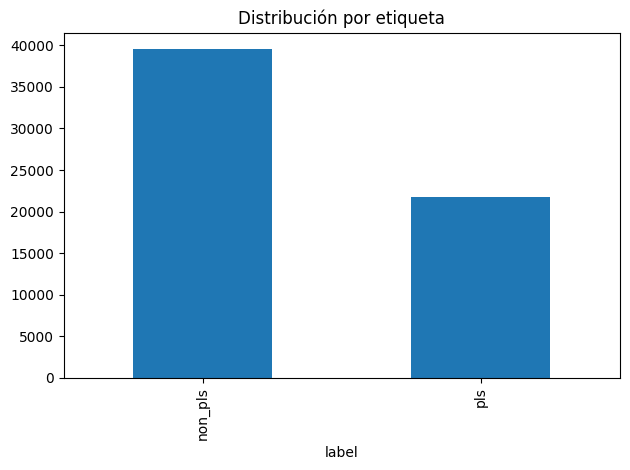

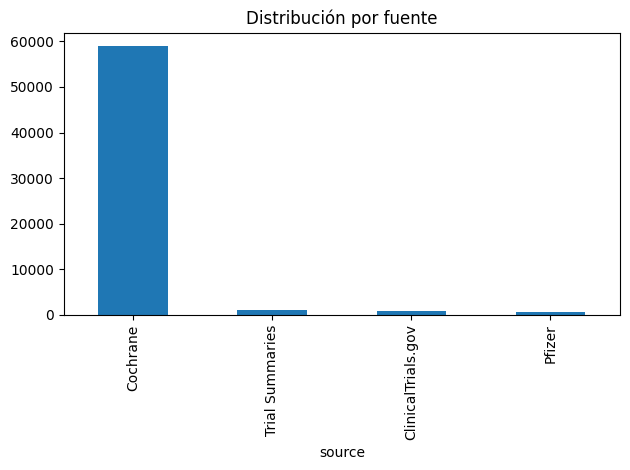

In [4]:
df = df_raw.copy()
if not df.empty and DEDUPLICATE:
    before = len(df)
    key = df['text'].map(normalize_for_dedup)
    df = df.loc[~key.duplicated()].reset_index(drop=True)
    after = len(df)
    print(f'Deduplicación: {before} -> {after} (elim {before-after})')
else:
    print('Deduplicación desactivada o DF vacío.')

print('\nEtiquetas:'); print(df['label'].value_counts())
print('\nFuentes:'); print(df['source'].value_counts())

plt.figure()
df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución por etiqueta')
plt.tight_layout(); plt.show()

plt.figure()
df['source'].value_counts().plot(kind='bar')
plt.title('Distribución por fuente')
plt.tight_layout(); plt.show()

In [5]:

def make_splits(df: pd.DataFrame, test_size=0.2, val_size=0.15, random_state=17):
    has_split = df['subset'].isin(['train','test']).any()
    if has_split:
        train_df = df[df['subset']=='train'].copy()
        test_df  = df[df['subset']=='test'].copy()
        uns = df[df['subset']=='unspecified'].copy()
        parts_tr = [train_df]; parts_te = [test_df]
        if not uns.empty:
            for src, g in uns.groupby('source'):
                if g['label_int'].nunique()<2 or len(g) < 10:
                    parts_tr.append(g)
                else:
                    gtr, gte = train_test_split(g, test_size=test_size, stratify=g['label_int'], random_state=random_state)
                    parts_tr.append(gtr); parts_te.append(gte)
        train_df = pd.concat(parts_tr, ignore_index=True)
        test_df  = pd.concat(parts_te, ignore_index=True)
    else:
        train_df, test_df = train_test_split(df, test_size=test_size, stratify=df['label_int'], random_state=random_state)
    if val_size and val_size>0:
        tr_df, val_df = train_test_split(train_df, test_size=val_size, stratify=train_df['label_int'], random_state=random_state)
    else:
        tr_df, val_df = train_df, pd.DataFrame()
    tr_df = shuffle(tr_df, random_state=random_state).reset_index(drop=True)
    val_df = shuffle(val_df, random_state=random_state).reset_index(drop=True)
    test_df = shuffle(test_df, random_state=random_state).reset_index(drop=True)
    return tr_df, val_df, test_df

df_train, df_val, df_test = make_splits(df, test_size=0.2, val_size=0.15, random_state=17)
print('Sizes -> train:', len(df_train), 'val:', len(df_val), 'test:', len(df_test))
for name, d in [('train',df_train),('val',df_val),('test',df_test)]:
    print(f"\n{name} por etiqueta:"); print(d['label'].value_counts())

Sizes -> train: 42058 val: 7423 test: 11844

train por etiqueta:
label
non_pls    26973
pls        15085
Name: count, dtype: int64

val por etiqueta:
label
non_pls    4761
pls        2662
Name: count, dtype: int64

test por etiqueta:
label
non_pls    7791
pls        4053
Name: count, dtype: int64


In [6]:

def metrics_binary(y_true, y_pred, y_proba=None, prefix=''):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    res = {f'{prefix}accuracy': acc, f'{prefix}precision_macro': prec, f'{prefix}recall_macro': rec, f'{prefix}f1_macro': f1}
    if y_proba is not None:
        try:
            res[f'{prefix}roc_auc'] = roc_auc_score(y_true, y_proba)
        except Exception:
            res[f'{prefix}roc_auc'] = None
        try:
            res[f'{prefix}pr_auc'] = average_precision_score(y_true, y_proba)
        except Exception:
            res[f'{prefix}pr_auc'] = None
    return res

def plot_confusion(y_true, y_pred, title, path_png=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.xticks([0,1], ['non_pls','pls'])
    plt.yticks([0,1], ['non_pls','pls'])
    for (i,j),v in np.ndenumerate(cm):
        plt.text(j,i,str(v),ha='center',va='center')
    plt.tight_layout()
    if path_png:
        plt.savefig(path_png, dpi=140)
    plt.show()

def find_best_threshold(y_true, y_score):
    thr_grid = np.linspace(0.05,0.95,19)
    best_thr, best_f1 = 0.5, -1
    for thr in thr_grid:
        y_pred = (y_score>=thr).astype(int)
        f1 = metrics_binary(y_true, y_pred)['f1_macro']
        if f1>best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

In [7]:

def identity(x): return x

def build_vectorizer_union():
    word_v = ('word_tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=3, max_df=0.9,
                                            strip_accents='unicode', lowercase=True, sublinear_tf=True))
    char_v = ('char_tfidf', TfidfVectorizer(analyzer='char', ngram_range=(3,5), min_df=3, max_df=0.95,
                                            lowercase=True, sublinear_tf=True))
    union = FeatureUnion([
        ('pass_word', Pipeline([('id1', FunctionTransformer(func=identity, validate=False)), word_v])),
        ('pass_char', Pipeline([('id2', FunctionTransformer(func=identity, validate=False)), char_v]))
    ])
    return union

def build_logreg_pipeline(C=2.0, class_weight='balanced', max_iter=2000):
    vec = build_vectorizer_union()
    clf = LogisticRegression(C=C, class_weight=class_weight, max_iter=max_iter, solver='saga')
    return Pipeline([('features', vec), ('clf', clf)])

def build_svm_pipeline(C=1.0):
    vec = build_vectorizer_union()
    base = Pipeline([('features', vec), ('clf', LinearSVC(C=C))])
    return Pipeline([('cal', CalibratedClassifierCV(base, cv=3, method='sigmoid'))])

SPARSE_MODELS = {
    'tfidf_logreg': build_logreg_pipeline(),
    'tfidf_svm_cal': build_svm_pipeline()
}

Xtr, ytr = df_train['text'].tolist(), df_train['label_int'].astype(int).values
Xval, yval = df_val['text'].tolist(), df_val['label_int'].astype(int).values
Xte, yte   = df_test['text'].tolist(), df_test['label_int'].astype(int).values

results = []
trained = {}

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=17)
for name, pipe in SPARSE_MODELS.items():
    print(f"\nEntrenando (CV 3-fold): {name}")
    fold_f1 = []
    for fold,(tr_idx, va_idx) in enumerate(skf.split(Xtr, ytr)):
        X_tr = [Xtr[i] for i in tr_idx]; y_tr = ytr[tr_idx]
        X_va = [Xtr[i] for i in va_idx]; y_va = ytr[va_idx]
        pipe.fit(X_tr, y_tr)
        y_hat = pipe.predict(X_va)
        try:
            y_pro = pipe.predict_proba(X_va)[:,1]
        except Exception:
            y_pro = None
        m = metrics_binary(y_va, y_hat, y_pro, prefix=f'cv{fold+1}_')
        fold_f1.append(m[f'cv{fold+1}_f1_macro'])
        print(f"  Fold {fold+1} F1_macro={m[f'cv{fold+1}_f1_macro']:.4f}")
    print(f"CV F1_macro mean={np.mean(fold_f1):.4f}")

    pipe.fit(Xtr, ytr)
    trained[name] = pipe

    y_hat_val = pipe.predict(Xval)
    y_pro_val = None
    try: y_pro_val = pipe.predict_proba(Xval)[:,1]
    except Exception: pass
    res_val = metrics_binary(yval, y_hat_val, y_pro_val, prefix='val_')

    thr = 0.5
    if y_pro_val is not None:
        thr, best_f1 = find_best_threshold(yval, y_pro_val)
        y_hat_val_thr = (y_pro_val >= thr).astype(int)
        res_val_thr = metrics_binary(yval, y_hat_val_thr, y_pro_val, prefix='val_thr_')
        res_val.update({'val_best_thr':thr, 'val_thr_f1_macro':res_val_thr['val_thr_f1_macro']})

    y_hat_test = pipe.predict(Xte)
    try: y_pro_test = pipe.predict_proba(Xte)[:,1]
    except Exception: y_pro_test = None
    if y_pro_test is not None:
        y_hat_test_thr = (y_pro_test >= thr).astype(int)
        res_test = metrics_binary(yte, y_hat_test_thr, y_pro_test, prefix='test_')
    else:
        res_test = metrics_binary(yte, y_hat_test, None, prefix='test_')

    results.append({'model':name, **res_val, **res_test})

pd.DataFrame(results).to_csv(OUTPUT_DIR/'results_sparse.csv', index=False)
pd.DataFrame(results)


Entrenando (CV 3-fold): tfidf_logreg
  Fold 1 F1_macro=0.9984
  Fold 2 F1_macro=0.9981
  Fold 3 F1_macro=0.9979
CV F1_macro mean=0.9981

Entrenando (CV 3-fold): tfidf_svm_cal
  Fold 1 F1_macro=0.9995
  Fold 2 F1_macro=0.9990
  Fold 3 F1_macro=0.9988
CV F1_macro mean=0.9991


,model,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,val_pr_auc,val_best_thr,val_thr_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,test_pr_auc
0,tfidf_logreg,0.998922,0.998502,0.999160,0.998829,0.999999,0.999997,0.70,0.999414,0.996960,0.996048,0.997216,0.996628,0.999891,0.999784
1,tfidf_svm_cal,0.999461,0.999414,0.999414,0.999414,0.999999,0.999998,0.65,0.999561,0.997383,0.996544,0.997655,0.997096,0.999935,0.999872


## Guardar resultados

In [8]:
from pathlib import Path
import joblib, json, sklearn
from datetime import datetime

BASE_DIR = Path(OUTPUT_DIR) / "sparse_models"
BASE_DIR.mkdir(parents=True, exist_ok=True)

# collect best thresholds per model from your loop (default to 0.5 if none)
best_thr_by_model = {}
for row in results:
    name = row['model']
    thr = row.get('val_best_thr', None)
    if thr is None and f"test_f1_macro" in row:  # fallback
        thr = 0.5
    best_thr_by_model[name] = thr

def _get_classes(pipe):
    # last estimator can be 'cal' (CalibratedClassifierCV) or 'clf'
    if hasattr(pipe, "named_steps"):
        if "cal" in pipe.named_steps and hasattr(pipe.named_steps["cal"], "classes_"):
            return pipe.named_steps["cal"].classes_
        if "clf" in pipe.named_steps and hasattr(pipe.named_steps["clf"], "classes_"):
            return pipe.named_steps["clf"].classes_
    # some pipelines expose classes_ at top level after fit
    return getattr(pipe, "classes_", None)

saved_paths = {}
for name, pipe in trained.items():
    model_dir = BASE_DIR / name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) save the full pipeline (vectorizers + clf/calibrator)
    joblib.dump(pipe, model_dir / "model.joblib", compress=("xz", 3))

    # 2) save metadata (threshold, classes, versions, metrics snapshot)
    classes = _get_classes(pipe)
    meta = {
        "name": name,
        "created_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
        "sklearn_version": sklearn.__version__,
        "threshold": float(best_thr_by_model.get(name)) if best_thr_by_model.get(name) is not None else None,
        "classes": classes.tolist() if classes is not None else None,
    }
    with open(model_dir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    # 3) (optional) store the row of validation/test metrics for quick reference
    row = next((r for r in results if r["model"] == name), None)
    if row is not None:
        with open(model_dir / "metrics.json", "w") as f:
            json.dump(row, f, indent=2)

    saved_paths[name] = str(model_dir)

print("Saved models:")
for k, v in saved_paths.items():
    print(f" - {k}: {v}")

/tmp/ipython-input-512378272.py:39: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",


Saved models:
 - tfidf_logreg: outputs_pls_classifier_v2/sparse_models/tfidf_logreg
 - tfidf_svm_cal: outputs_pls_classifier_v2/sparse_models/tfidf_svm_cal


In [9]:
import pandas as pd
from pathlib import Path

RESULTS_DF = pd.DataFrame(results)
RESULTS_DF.to_csv(OUTPUT_DIR / 'results_sparse.csv', index=False)
RESULTS_DF.to_parquet(OUTPUT_DIR / 'results_sparse.parquet', index=False)  # optional
RESULTS_DF.head()


,model,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,val_pr_auc,val_best_thr,val_thr_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,test_pr_auc
0,tfidf_logreg,0.998922,0.998502,0.999160,0.998829,0.999999,0.999997,0.70,0.999414,0.996960,0.996048,0.997216,0.996628,0.999891,0.999784
1,tfidf_svm_cal,0.999461,0.999414,0.999414,0.999414,0.999999,0.999998,0.65,0.999561,0.997383,0.996544,0.997655,0.997096,0.999935,0.999872


In [10]:
import json, platform, sklearn, numpy as np
from joblib import dump
from datetime import datetime

MODEL_DIR = Path(OUTPUT_DIR) / "models_sparse"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Build a {model_name: best_threshold or 0.5} map from results
best_thr_map = {}
for row in results:
    name = row["model"]
    thr = row.get("val_best_thr", 0.5)
    best_thr_map[name] = float(thr)

# Save each trained pipeline (already includes vectorizers)
for name, pipe in trained.items():
    dump(pipe, MODEL_DIR / f"{name}.joblib", compress=3)

# Save thresholds, metrics-by-model, and environment info
metrics_by_model = {r["model"]: r for r in results}
artifact_index = {
    "saved_at": datetime.utcnow().isoformat() + "Z",
    "python": platform.python_version(),
    "sklearn": sklearn.__version__,
    "numpy": np.__version__,
    "models": [
        {
            "name": name,
            "file": f"{name}.joblib",
            "best_threshold": best_thr_map.get(name, 0.5),
            "metrics": metrics_by_model.get(name, {})
        }
        for name in trained.keys()
    ]
}
with open(MODEL_DIR / "thresholds.json", "w") as f:
    json.dump(best_thr_map, f, indent=2)
with open(MODEL_DIR / "model_index.json", "w") as f:
    json.dump(artifact_index, f, indent=2)


/tmp/ipython-input-1959815216.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "saved_at": datetime.utcnow().isoformat() + "Z",


## Cargar resultados

In [ ]:
# --- Load a saved sparse pipeline and predict ---
def load_sparse_model(model_dir):
    model_dir = Path(model_dir)
    pipe = joblib.load(model_dir / "model.joblib")
    with open(model_dir / "meta.json") as f:
        meta = json.load(f)
    return pipe, meta

def predict_with_threshold(pipe, meta, texts):
    # If model has predict_proba, use threshold; otherwise fall back to predict
    thr = meta.get("threshold", 0.5)
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(texts)
        # handle binary vs multiclass gracefully
        if proba.ndim == 2 and proba.shape[1] >= 2:
            pos_idx = 1  # assuming your label_int uses 0/1 and metrics expect p(class 1)
            y_prob = proba[:, pos_idx]
            y_hat = (y_prob >= thr).astype(int)
            return y_hat, y_prob
        else:
            # unexpected shape; degrade to decision_function/predict
            y_hat = pipe.predict(texts)
            return y_hat, None
    elif hasattr(pipe, "decision_function"):
        scores = pipe.decision_function(texts)
        # approximate probabilities via sigmoid if you really need them
        y_prob = 1.0 / (1.0 + np.exp(-scores))
        y_hat = (y_prob >= thr).astype(int)
        return y_hat, y_prob
    else:
        y_hat = pipe.predict(texts)
        return y_hat, None

# Example usage:
pipe, meta = load_sparse_model(BASE_DIR / "tfidf_svm_cal")
y_hat, y_prob = predict_with_threshold(pipe, meta, ["sample text 1", "sample text 2"])

print(f"Results Hat -  {y_hat} - Prob {y_prob}")

NameError: name 'joblib' is not defined

In [ ]:

# === Transformers: Fine-tuning cabeza lineal ===
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
    import torch, datasets as hfds

    MODEL_NAME = 'distilbert-base-uncased'  # Cambia a 'dccuchile/bert-base-spanish-wwm-uncased' si prefieres ES
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

    def tokenize_batch(texts):
        return tokenizer(texts, truncation=True, padding=True, max_length=256)

    ds_train = hfds.Dataset.from_pandas(df_train[['text','label_int']].rename(columns={'label_int':'labels'}))
    ds_val   = hfds.Dataset.from_pandas(df_val[['text','label_int']].rename(columns={'label_int':'labels'}))
    ds_test  = hfds.Dataset.from_pandas(df_test[['text','label_int']].rename(columns={'label_int':'labels'}))

    ds_train = ds_train.map(lambda e: tokenize_batch(e['text']), batched=True, remove_columns=['text'])
    ds_val   = ds_val.map(lambda e: tokenize_batch(e['text']), batched=True, remove_columns=['text'])
    ds_test  = ds_test.map(lambda e: tokenize_batch(e['text']), batched=True, remove_columns=['text'])

    model_lin = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    def compute_metrics_fn(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        proba = (torch.softmax(torch.tensor(logits), dim=-1)[:,1]).numpy()
        return metrics_binary(labels, preds, proba)

    args = TrainingArguments(
        output_dir=str(OUTPUT_DIR/'hf_linear'),
        evaluation_strategy='epoch',
        save_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=50,
        report_to=[]
    )

    trainer_lin = Trainer(
        model=model_lin,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn
    )

    print("Entrenando DistilBERT (lineal)...")
    trainer_lin.train()

    eval_val = trainer_lin.evaluate(ds_val)
    eval_test = trainer_lin.evaluate(ds_test)
    print("VAL:", eval_val); print("TEST:", eval_test)

    logits_test = np.array(trainer_lin.predict(ds_test).predictions)
    proba_test_ctx_linear = (torch.softmax(torch.tensor(logits_test), dim=-1)[:,1]).numpy()

    results.append({'model':'transformer_linear', **{f'val_{k}':v for k,v in eval_val.items()}, **{f'test_{k}':v for k,v in eval_test.items()}})

except Exception as e:
    print("⚠️ No se pudo entrenar el modelo contextual (lineal). Error:", e)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Entrenando DistilBERT (lineal)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Roc Auc,Pr Auc
1,0.003400,0.006406,0.998922,0.998746,0.998911,0.998829,0.999978,0.999963
2,0.000000,0.003603,0.999192,0.999121,0.999121,0.999121,0.999996,0.999993


VAL: {'eval_loss': 0.0036029652692377567, 'eval_accuracy': 0.999191701468409, 'eval_precision_macro': 0.9991214540379502, 'eval_recall_macro': 0.9991214540379502, 'eval_f1_macro': 0.9991214540379502, 'eval_roc_auc': 0.9999963704598991, 'eval_pr_auc': 0.9999934865344717, 'eval_runtime': 59.9596, 'eval_samples_per_second': 123.8, 'eval_steps_per_second': 3.869, 'epoch': 2.0}
TEST: {'eval_loss': 0.006272108294069767, 'eval_accuracy': 0.9984802431610942, 'eval_precision_macro': 0.9979621547083192, 'eval_recall_macro': 0.9986672545643538, 'eval_f1_macro': 0.9983133178678082, 'eval_roc_auc': 0.9999914494518671, 'eval_pr_auc': 0.9999835050398413, 'eval_runtime': 93.4855, 'eval_samples_per_second': 126.693, 'eval_steps_per_second': 3.969, 'epoch': 2.0}


In [ ]:
# --- Guardar "best model" y tokenizer de forma explícita ---
BEST_DIR = OUTPUT_DIR / 'hf_linear' / 'best'
BEST_DIR.mkdir(parents=True, exist_ok=True)

# El Trainer ya tiene cargado el mejor modelo en memoria gracias a load_best_model_at_end=True
trainer_lin.save_model(str(BEST_DIR))     # guarda config + pesos (safetensors)
tokenizer.save_pretrained(str(BEST_DIR))  # guarda vocab/tokenizer

# (Opcional) persistir los mapeos de etiquetas si los tienes
import json
with open(BEST_DIR / "label_mapping.json", "w") as f:
    json.dump(
        {
            "id2label": getattr(trainer_lin.model.config, "id2label", {0:"LABEL_0",1:"LABEL_1"}),
            "label2id": getattr(trainer_lin.model.config, "label2id", {"LABEL_0":0,"LABEL_1":1}),
        },
        f, indent=2
    )

# (Opcional) guardar métricas
import json
with open(BEST_DIR / "metrics_val.json", "w") as f: json.dump(eval_val, f, indent=2)
with open(BEST_DIR / "metrics_test.json", "w") as f: json.dump(eval_test, f, indent=2)


In [ ]:

# === Transformers: Cabeza MLP ===
try:
    from transformers import AutoConfig, AutoModel, Trainer, TrainingArguments
    import torch.nn as nn, torch

    class BertWithMLPHead(nn.Module):
        def __init__(self, base_name='distilbert-base-uncased', hidden=256, dropout=0.1, num_labels=2):
            super().__init__()
            self.config = AutoConfig.from_pretrained(base_name)
            self.backbone = AutoModel.from_pretrained(base_name, config=self.config)
            hdim = self.backbone.config.hidden_size
            self.classifier = nn.Sequential(
                nn.Linear(hdim, hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden, num_labels)
            )
        def forward(self, input_ids=None, attention_mask=None, labels=None):
            out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
            pooled = out.last_hidden_state[:,0,:]
            logits = self.classifier(pooled)
            loss = None
            if labels is not None:
                loss_fct = nn.CrossEntropyLoss()
                loss = loss_fct(logits, labels)
            return {'loss': loss, 'logits': logits}

    model_mlp = BertWithMLPHead()

    args_mlp = TrainingArguments(
        output_dir=str(OUTPUT_DIR/'hf_mlp'),
        evaluation_strategy='epoch',
        save_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=50,
        report_to=[]
    )

    def compute_metrics_fn(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        proba = (torch.softmax(torch.tensor(logits), dim=-1)[:,1]).numpy()
        return metrics_binary(labels, preds, proba)

    trainer_mlp = Trainer(
        model=model_mlp,
        args=args_mlp,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn
    )

    print("Entrenando DistilBERT (MLP)...")
    trainer_mlp.train()

    eval_val_mlp = trainer_mlp.evaluate(ds_val)
    eval_test_mlp = trainer_mlp.evaluate(ds_test)
    print("VAL (MLP):", eval_val_mlp); print("TEST (MLP):", eval_test_mlp)

    logits_test_mlp = np.array(trainer_mlp.predict(ds_test).predictions)
    proba_test_ctx_mlp = (torch.softmax(torch.tensor(logits_test_mlp), dim=-1)[:,1]).numpy()

    results.append({'model':'transformer_mlp', **{f'val_{k}':v for k,v in eval_val_mlp.items()}, **{f'test_{k}':v for k,v in eval_test_mlp.items()}})

except Exception as e:
    print("⚠️ No se pudo entrenar el modelo contextual (MLP). Error:", e)

In [ ]:

# === Frozen embeddings (Sentence-Transformers) + LogReg ===
try:
    from sentence_transformers import SentenceTransformer
    print("Cargando sentence-transformer...")
    st_model = SentenceTransformer('all-MiniLM-L6-v2')

    def encode_batch(texts, batch_size=256):
        return st_model.encode(texts, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=False, normalize_embeddings=True)

    Xtr_emb = encode_batch(df_train['text'].tolist())
    Xval_emb = encode_batch(df_val['text'].tolist())
    Xte_emb  = encode_batch(df_test['text'].tolist())

    lr_ctx = LogisticRegression(C=2.0, class_weight='balanced', max_iter=2000, solver='saga')
    lr_ctx.fit(Xtr_emb, ytr)

    y_hat_val = lr_ctx.predict(Xval_emb)
    y_pro_val = lr_ctx.predict_proba(Xval_emb)[:,1]
    res_val = metrics_binary(yval, y_hat_val, y_pro_val, prefix='val_')

    thr_ctx, _ = find_best_threshold(yval, y_pro_val)
    y_pro_test = lr_ctx.predict_proba(Xte_emb)[:,1]
    y_hat_test = (y_pro_test >= thr_ctx).astype(int)
    res_test = metrics_binary(yte, y_hat_test, y_pro_test, prefix='test_')

    results.append({'model':'sentencetrf_logreg', **res_val, **res_test})
    proba_test_sentencetrf = y_pro_test

except Exception as e:
    print("⚠️ No se pudo ejecutar sentence-transformers. Error:", e)

⚠️ No se pudo ejecutar sentence-transformers. Error: No module named 'sentence_transformers'


In [ ]:

# === Ensamble simple (promedio de probabilidades disponibles) ===
def safe_proba(model, X):
    try: return model.predict_proba(X)[:,1]
    except Exception: return None

probas = []
if results:
    df_res = pd.DataFrame(results)
    if 'val_f1_macro' in df_res.columns:
        best_sparse = df_res[df_res['model'].str.startswith('tfidf')].sort_values('val_f1_macro', ascending=False)['model'].head(1).to_list()
    else:
        best_sparse = []
    if best_sparse:
        p = safe_proba(trained[best_sparse[0]], Xte)
        if p is not None: probas.append(p)

try:
    if 'proba_test_ctx_linear' in globals(): probas.append(proba_test_ctx_linear)
except: pass
try:
    if 'proba_test_ctx_mlp' in globals(): probas.append(proba_test_ctx_mlp)
except: pass
try:
    if 'proba_test_sentencetrf' in globals(): probas.append(proba_test_sentencetrf)
except: pass

if len(probas)>=2:
    P = np.vstack(probas)
    ens_proba = P.mean(axis=0)
    y_hat_ens = (ens_proba >= 0.5).astype(int)
    res_ens = metrics_binary(yte, y_hat_ens, ens_proba, prefix='test_')
    results.append({'model':'ensemble_avg_proba', **res_ens})
    print("Ensamble evaluado en test.")
else:
    print("No hay suficientes probabilidades para ensamble.")

No hay suficientes probabilidades para ensamble.


In [ ]:

# === Análisis de errores (fix) para mejor scikit por F1 en val ===
def error_analysis(model, X_test, y_test, df_test_meta: pd.DataFrame, max_rows=10):
    y_true = np.asarray(y_test)
    y_pred = np.asarray(model.predict(X_test))
    assert len(y_pred)==len(y_true)==len(df_test_meta)
    err_idx = np.where(y_pred != y_true)[0]
    errs = df_test_meta.iloc[err_idx].copy().reset_index(drop=True)
    errs['y_true'] = y_true[err_idx]
    errs['y_pred'] = y_pred[err_idx]
    try:
        y_proba = model.predict_proba(X_test)[:,1]
        errs['prob_pls'] = y_proba[err_idx]
    except Exception:
        pass
    inv = {0:'non_pls',1:'pls'}
    errs['y_true_label'] = errs['y_true'].map(inv)
    errs['y_pred_label'] = errs['y_pred'].map(inv)
    errs['error_type'] = np.where((errs['y_true']==0)&(errs['y_pred']==1),'FP','FN')
    return errs.head(max_rows)

df_sparse = pd.DataFrame([r for r in results if r['model'].startswith('tfidf')])
if not df_sparse.empty and 'val_f1_macro' in df_sparse.columns:
    best_name = df_sparse.sort_values('val_f1_macro', ascending=False)['model'].iloc[0]
    best_model = trained[best_name]
    err_df = error_analysis(best_model, Xte, yte, df_test, max_rows=20)
    cols = ['source','subset','label','y_true','y_pred','y_true_label','y_pred_label','error_type','n_chars','path']
    if 'prob_pls' in err_df.columns: cols.insert(3,'prob_pls')
    err_df[cols].to_csv(OUTPUT_DIR / f'errors_{best_name}.csv', index=False)
    err_df.head(10)
else:
    print("No fue posible seleccionar un mejor modelo scikit para error analysis.")

In [ ]:

res_df = pd.DataFrame(results)
res_df.to_csv(OUTPUT_DIR/'all_results.csv', index=False)
print('Resumen de resultados:'); res_df

Resumen de resultados:


,model,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,val_pr_auc,val_best_thr,val_thr_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,test_pr_auc
0,tfidf_logreg,0.998518,0.997942,0.998845,0.998391,0.999992,0.999985,0.75,0.999268,0.996201,0.995520,0.996047,0.995783,0.999892,0.999786
1,tfidf_svm_cal,0.999192,0.998876,0.999370,0.999122,0.999997,0.999994,0.55,0.999414,0.997383,0.996317,0.997892,0.997098,0.999931,0.999866
